🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: cuda | 注入噪声: 1.0%
🧬 正在提取 IEEE 118 节点底层物理拓扑...
📂 正在加载 118 节点数据集...
🔥 开始物理博弈训练 (强制注入 1.0% 测量噪声)...
Epoch 050/600 | Loss: 7.4941e+02 | LR: 1.00e-03
Epoch 100/600 | Loss: 8.0531e+02 | LR: 1.00e-03
Epoch 150/600 | Loss: 7.3103e+02 | LR: 1.00e-03
Epoch 200/600 | Loss: 7.5501e+02 | LR: 1.00e-03
Epoch 250/600 | Loss: 7.0586e+02 | LR: 5.00e-04
Epoch 300/600 | Loss: 6.9578e+02 | LR: 1.25e-04
Epoch 350/600 | Loss: 6.9458e+02 | LR: 6.25e-05
Epoch 400/600 | Loss: 6.9344e+02 | LR: 1.56e-05
Epoch 450/600 | Loss: 6.9309e+02 | LR: 3.91e-06
Epoch 500/600 | Loss: 6.9299e+02 | LR: 9.77e-07
Epoch 550/600 | Loss: 6.9283e+02 | LR: 2.44e-07
Epoch 600/600 | Loss: 6.9304e+02 | LR: 3.05e-08

📊 正在无污染测试集上进行精度审计...
🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: 1.0%)
   Overall MAE : 4.478849e-03 p.u.
   Overall RMSE: 6.519801e-03 p.u.
✅ 科研级高刷大图已保存为: ieee118_robustness_1pct_global.png


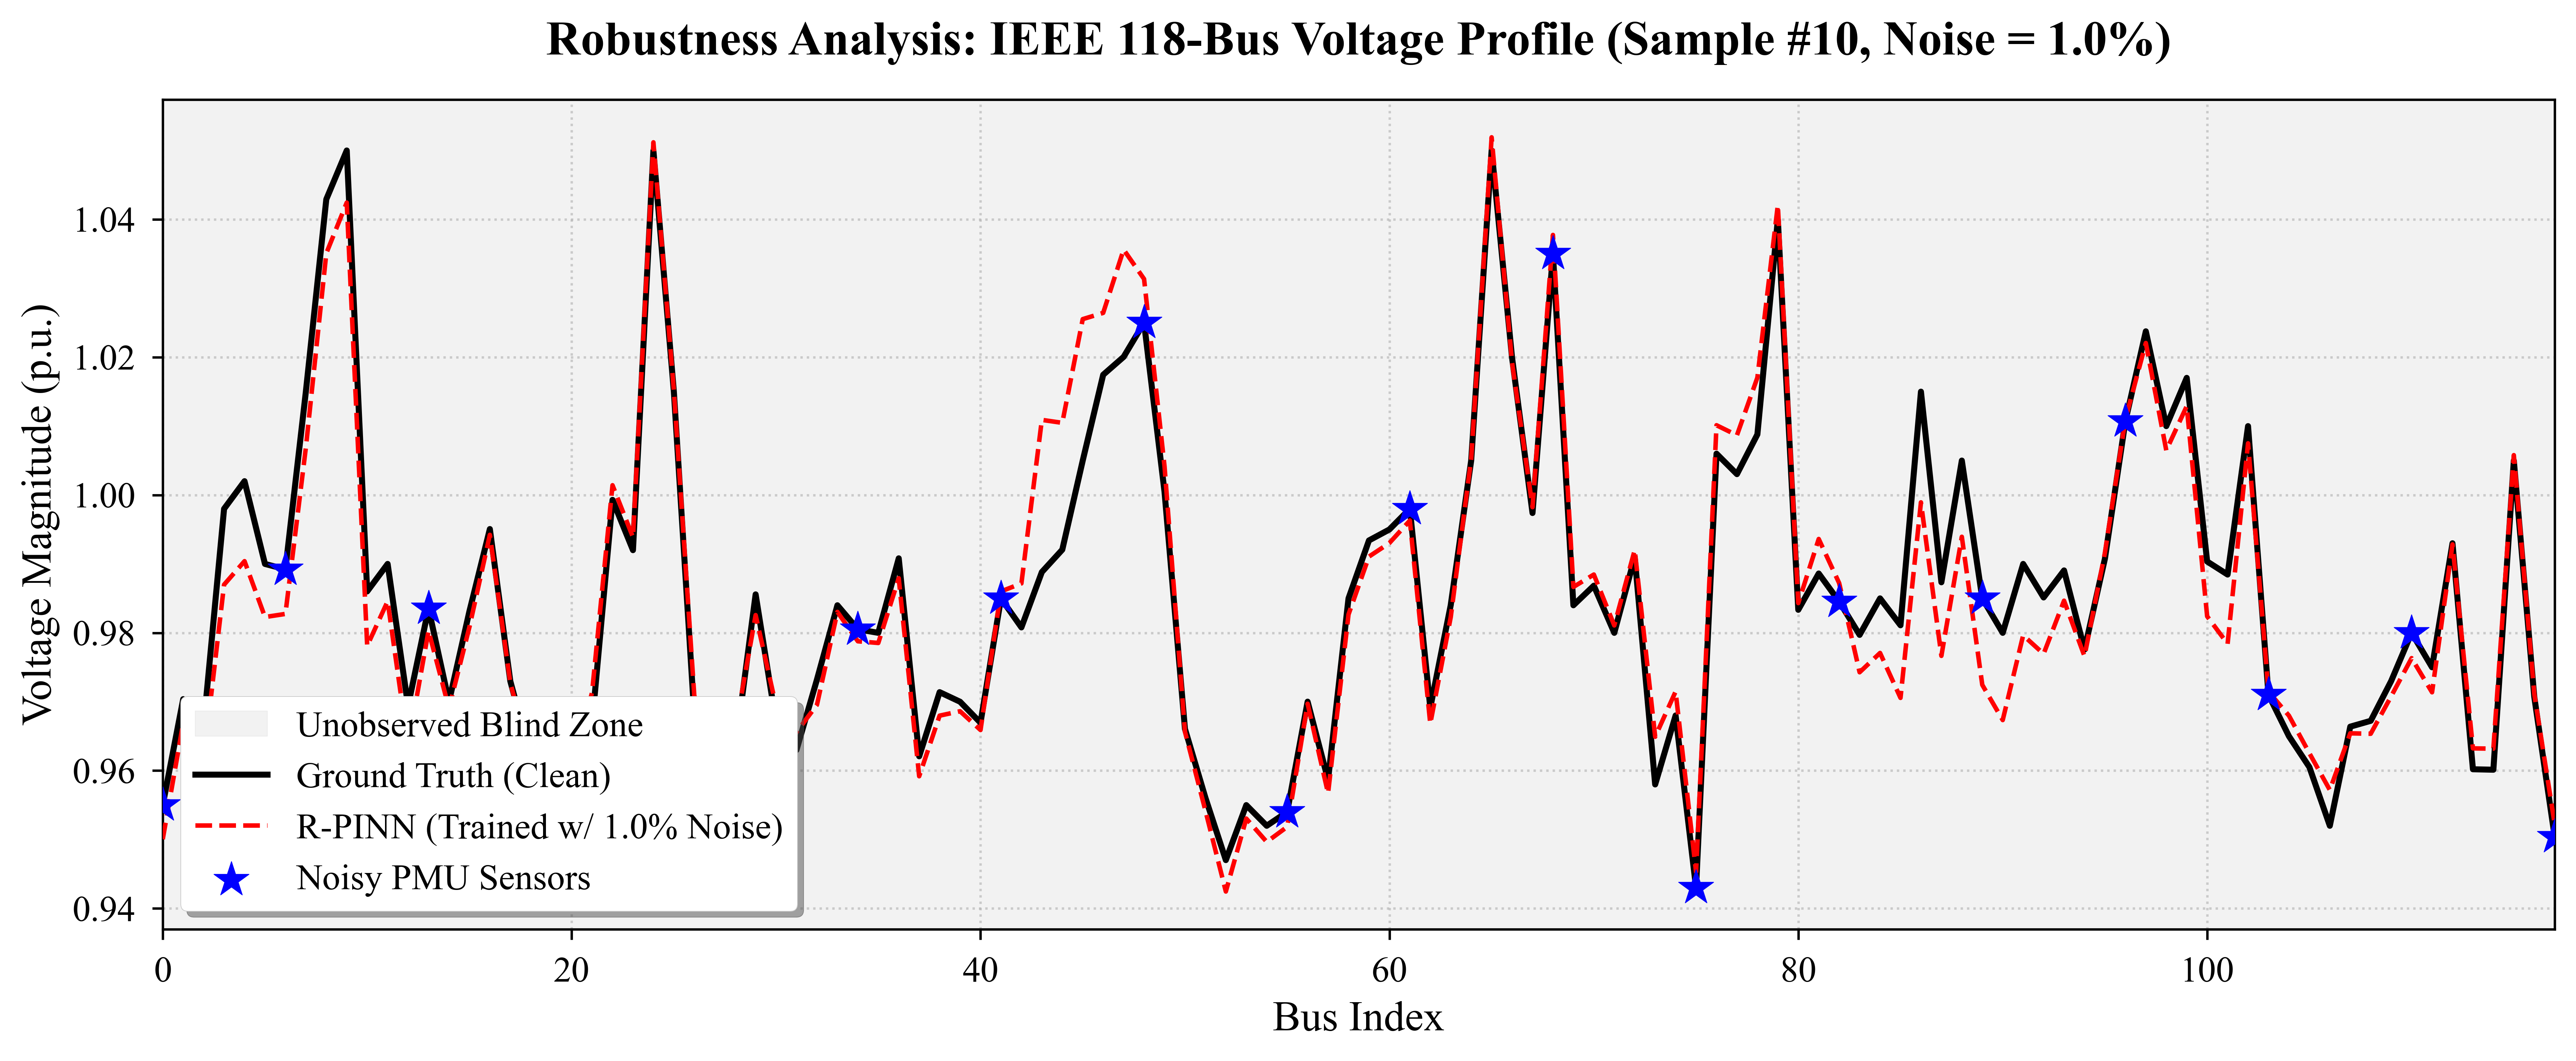

In [1]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：单 Cell 全流程 | 15% 观测 | 严格防泄漏 | 传感器噪声精准注入 | IEEE 标准大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定 (绝对复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.01 

print(f"🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置科研绘图字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取 (导纳矩阵)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

# 15% PMU 观测点
obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载与防泄漏处理
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声
        noisy_v_r = v_r.clone()
        clean_obs_v = noisy_v_r[:, obs_idx]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------

        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        l_phys = mse(pc, p_r) + mse(qc, q_r)
        
        # ⚠️ 观测 Loss 被污染数据欺骗
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.1), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对绝对真理的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_pred_all, _ = model(mask_tx)
    v_true_all = ty[:, 236:354]
    
    mae = torch.abs(v_pred_all - v_true_all).mean().item()
    rmse = torch.sqrt(torch.mean((v_pred_all - v_true_all)**2)).item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
    print(f"   Overall MAE : {mae:.6e} p.u.")
    print(f"   Overall RMSE: {rmse:.6e} p.u.")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (全局对比图)
# ==========================================
sid = 10
v_true_np = v_true_all[sid].cpu().numpy()
v_pred_np = v_pred_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, ax = plt.subplots(figsize=(12, 5), dpi=600)

# 绘制盲区阴影
ax.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')

# 核心曲线
ax.plot(nodes, v_true_np, 'k-', linewidth=2.0, label='Ground Truth (Clean)', zorder=3)
ax.plot(nodes, v_pred_np, 'r--', linewidth=1.5, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)

# 传感器标记
ax.scatter(obs_idx, v_true_np[obs_idx], color='blue', marker='*', s=150, label='Noisy PMU Sensors', zorder=5)

# 图表装饰
ax.set_title(f'Robustness Analysis: IEEE 118-Bus Voltage Profile (Sample #{sid}, Noise = {TEST_NOISE_LEVEL*100}%)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bus Index', fontsize=14)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=14)
ax.set_xlim(0, 117)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()

# 动态保存名字，防止覆盖
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_global.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 科研级高刷大图已保存为: {file_name}")
plt.show()

🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: cuda | 注入噪声: 2.0%
🧬 正在提取 IEEE 118 节点底层物理拓扑...
📂 正在加载 118 节点数据集...
🔥 开始物理博弈训练 (强制注入 2.0% 测量噪声)...
Epoch 050/600 | Loss: 7.6977e+02 | LR: 1.00e-03
Epoch 100/600 | Loss: 8.2415e+02 | LR: 5.00e-04
Epoch 150/600 | Loss: 7.2867e+02 | LR: 2.50e-04
Epoch 200/600 | Loss: 7.2372e+02 | LR: 6.25e-05
Epoch 250/600 | Loss: 7.2296e+02 | LR: 3.13e-05
Epoch 300/600 | Loss: 7.2217e+02 | LR: 7.81e-06
Epoch 350/600 | Loss: 7.2202e+02 | LR: 1.95e-06
Epoch 400/600 | Loss: 6.9501e+02 | LR: 1.95e-06
Epoch 450/600 | Loss: 6.4780e+02 | LR: 1.95e-06
Epoch 500/600 | Loss: 6.0500e+02 | LR: 1.95e-06
Epoch 550/600 | Loss: 5.7175e+02 | LR: 1.95e-06
Epoch 600/600 | Loss: 5.5041e+02 | LR: 1.95e-06

📊 正在无污染测试集上进行精度审计...
🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: 2.0%)
   Overall MAE : 4.595108e-03 p.u.
   Overall RMSE: 6.666732e-03 p.u.
✅ 科研级高刷大图已保存为: ieee118_robustness_2pct_global.png


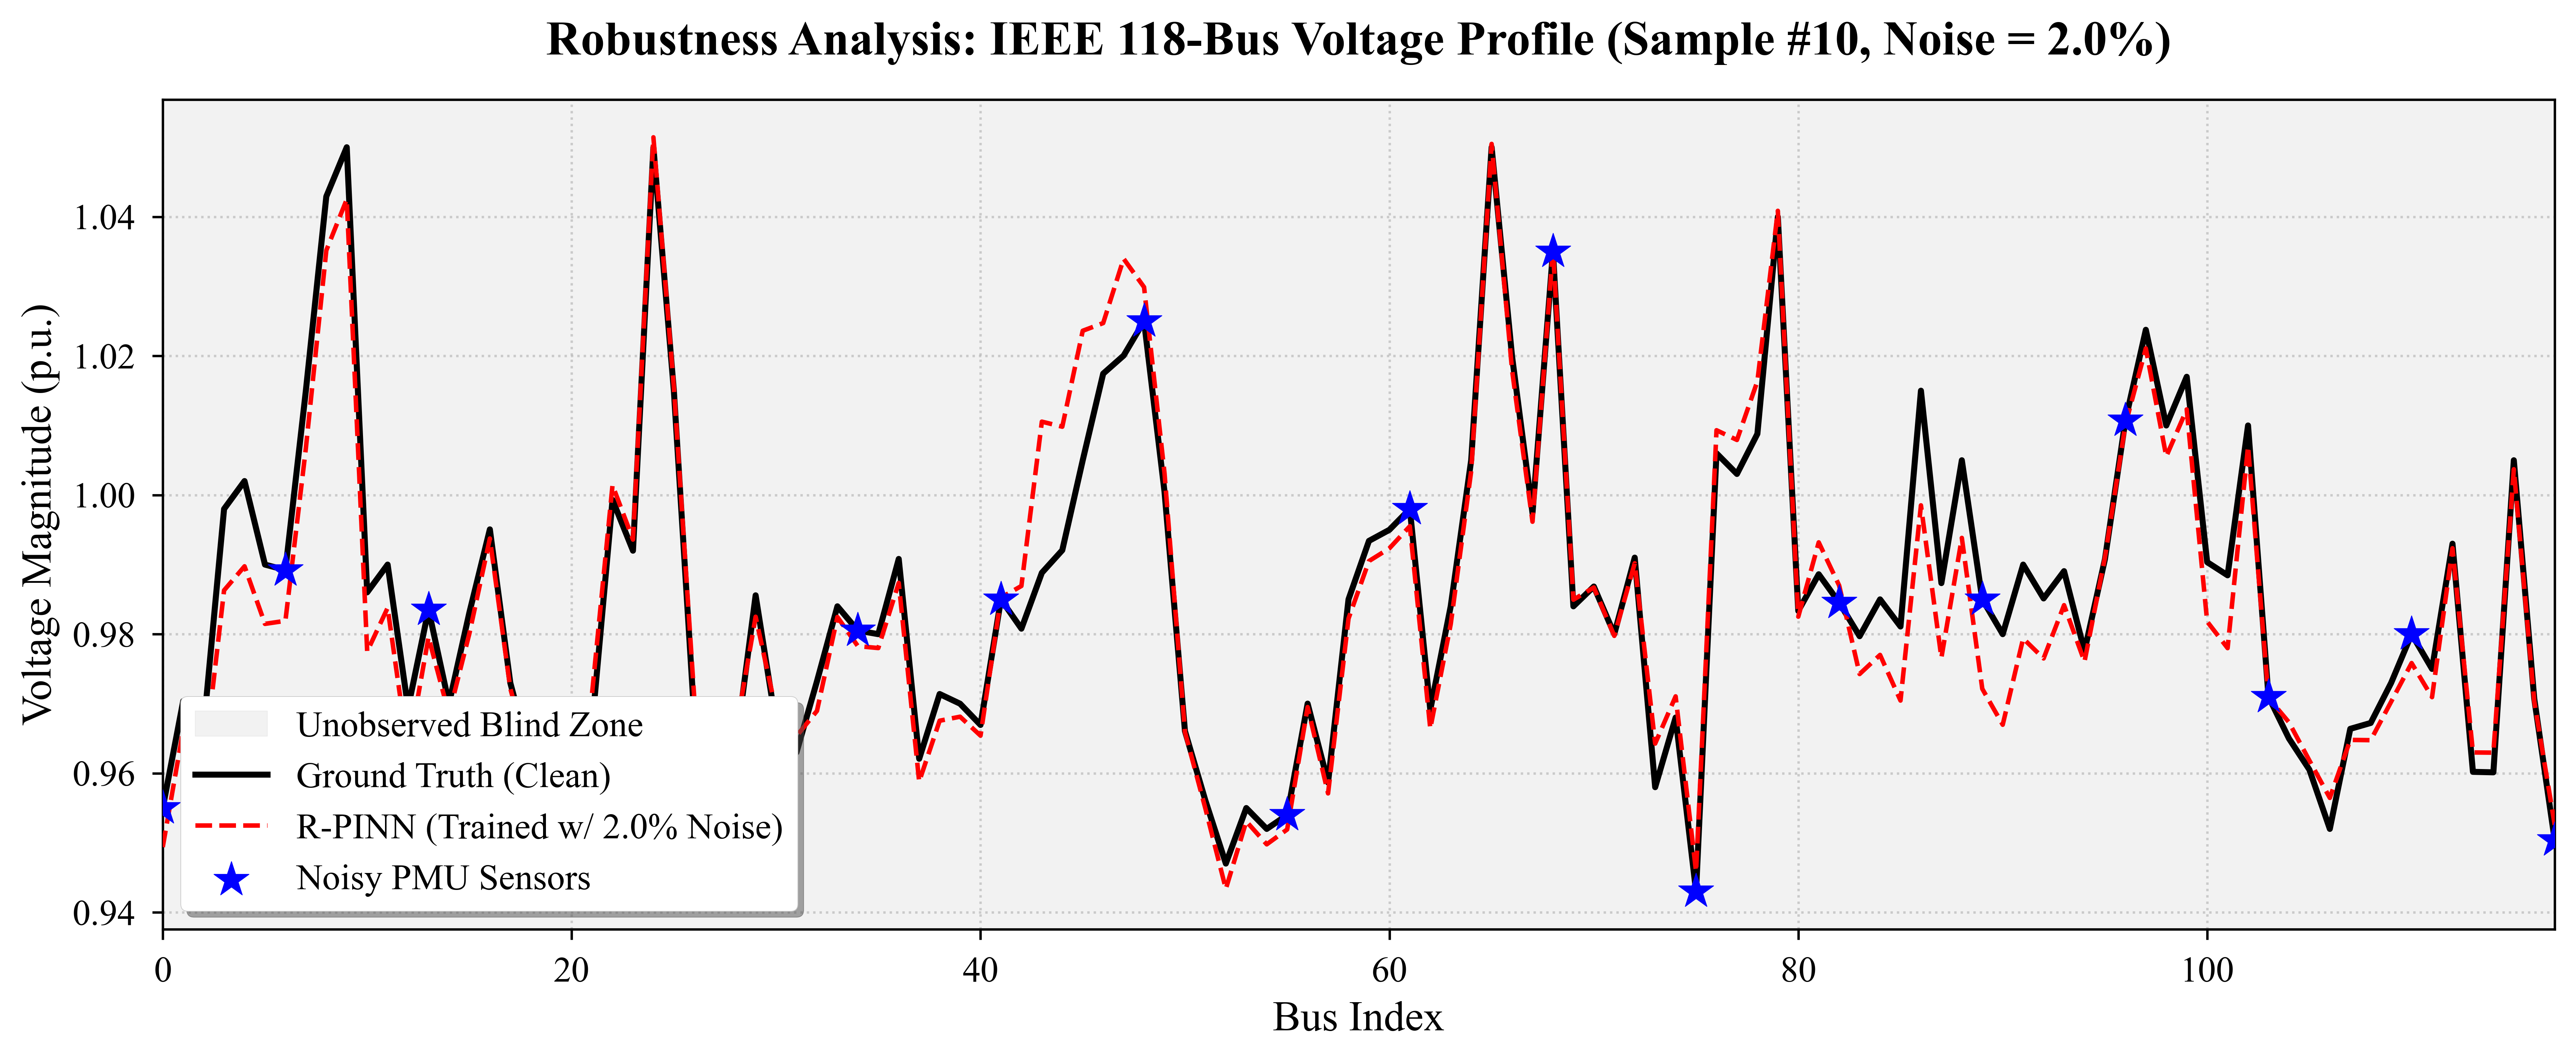

In [2]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：单 Cell 全流程 | 15% 观测 | 严格防泄漏 | 传感器噪声精准注入 | IEEE 标准大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定 (绝对复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.02 

print(f"🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置科研绘图字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取 (导纳矩阵)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

# 15% PMU 观测点
obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载与防泄漏处理
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声
        noisy_v_r = v_r.clone()
        clean_obs_v = noisy_v_r[:, obs_idx]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------

        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        l_phys = mse(pc, p_r) + mse(qc, q_r)
        
        # ⚠️ 观测 Loss 被污染数据欺骗
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.1), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对绝对真理的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_pred_all, _ = model(mask_tx)
    v_true_all = ty[:, 236:354]
    
    mae = torch.abs(v_pred_all - v_true_all).mean().item()
    rmse = torch.sqrt(torch.mean((v_pred_all - v_true_all)**2)).item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
    print(f"   Overall MAE : {mae:.6e} p.u.")
    print(f"   Overall RMSE: {rmse:.6e} p.u.")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (全局对比图)
# ==========================================
sid = 10
v_true_np = v_true_all[sid].cpu().numpy()
v_pred_np = v_pred_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, ax = plt.subplots(figsize=(12, 5), dpi=600)

# 绘制盲区阴影
ax.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')

# 核心曲线
ax.plot(nodes, v_true_np, 'k-', linewidth=2.0, label='Ground Truth (Clean)', zorder=3)
ax.plot(nodes, v_pred_np, 'r--', linewidth=1.5, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)

# 传感器标记
ax.scatter(obs_idx, v_true_np[obs_idx], color='blue', marker='*', s=150, label='Noisy PMU Sensors', zorder=5)

# 图表装饰
ax.set_title(f'Robustness Analysis: IEEE 118-Bus Voltage Profile (Sample #{sid}, Noise = {TEST_NOISE_LEVEL*100}%)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bus Index', fontsize=14)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=14)
ax.set_xlim(0, 117)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()

# 动态保存名字，防止覆盖
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_global.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 科研级高刷大图已保存为: {file_name}")
plt.show()

🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: cuda | 注入噪声: 3.0%
🧬 正在提取 IEEE 118 节点底层物理拓扑...
📂 正在加载 118 节点数据集...
🔥 开始物理博弈训练 (强制注入 3.0% 测量噪声)...
Epoch 050/600 | Loss: 8.9022e+02 | LR: 1.00e-03
Epoch 100/600 | Loss: 8.5989e+02 | LR: 1.00e-03
Epoch 150/600 | Loss: 8.5644e+02 | LR: 1.00e-03
Epoch 200/600 | Loss: 7.9890e+02 | LR: 1.00e-03
Epoch 250/600 | Loss: 7.7653e+02 | LR: 2.50e-04
Epoch 300/600 | Loss: 7.7294e+02 | LR: 1.25e-04
Epoch 350/600 | Loss: 7.7159e+02 | LR: 6.25e-05
Epoch 400/600 | Loss: 7.7058e+02 | LR: 1.56e-05
Epoch 450/600 | Loss: 7.6999e+02 | LR: 3.91e-06
Epoch 500/600 | Loss: 7.7012e+02 | LR: 9.77e-07
Epoch 550/600 | Loss: 7.6968e+02 | LR: 2.44e-07
Epoch 600/600 | Loss: 7.6856e+02 | LR: 2.44e-07

📊 正在无污染测试集上进行精度审计...
🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: 3.0%)
   Overall MAE : 4.478426e-03 p.u.
   Overall RMSE: 6.515877e-03 p.u.
✅ 科研级高刷大图已保存为: ieee118_robustness_3pct_global.png


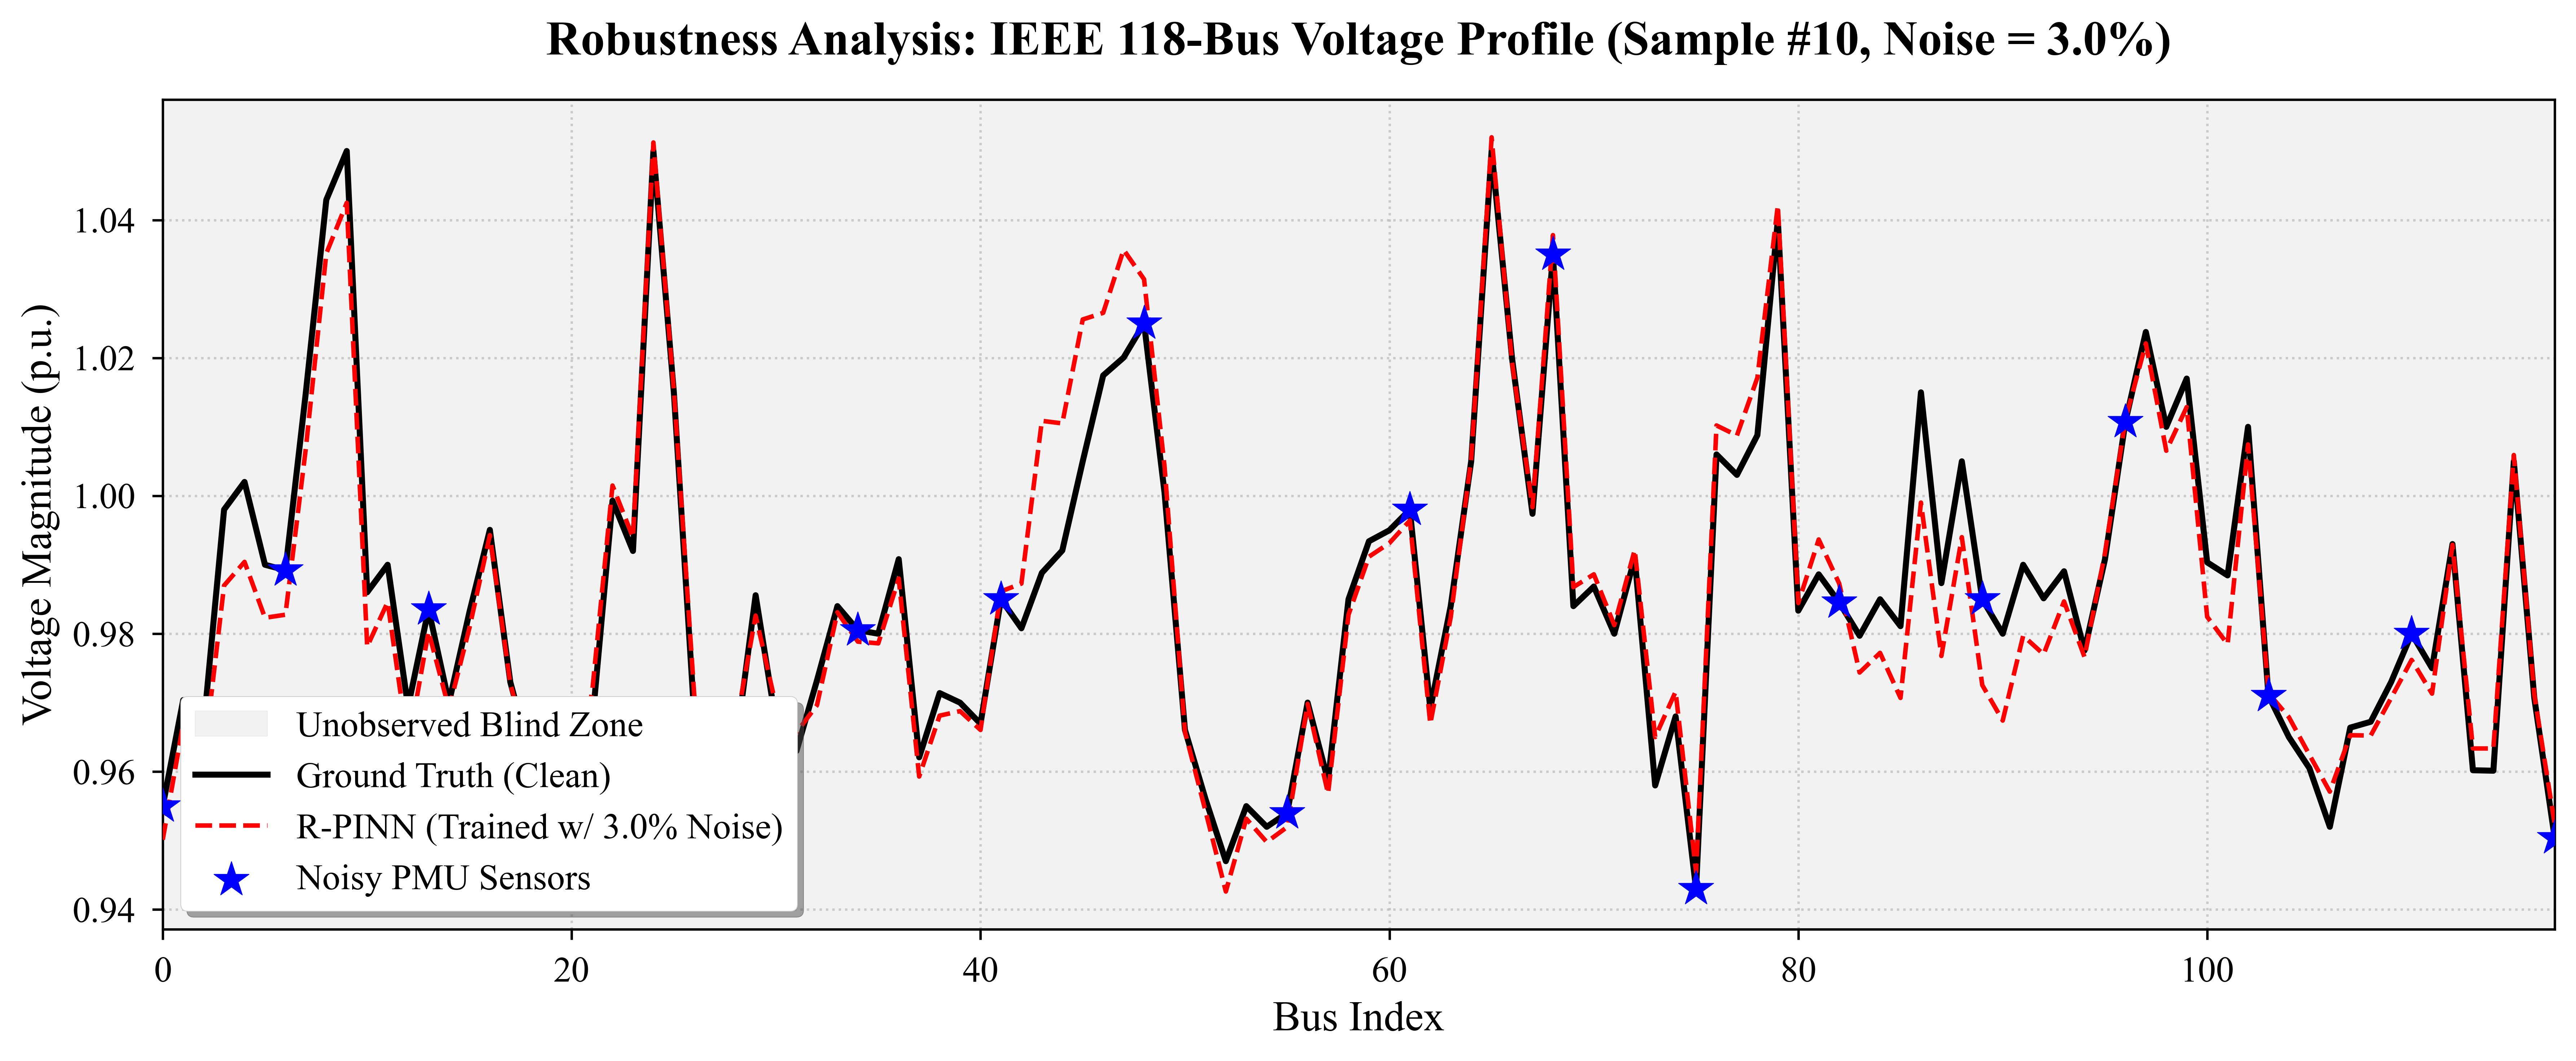

In [3]:
# ==============================================================================
# 🏆 IEEE 118-Bus R-PINN Robustness Test - Ultimate Platinum Edition
# 特点：单 Cell 全流程 | 15% 观测 | 严格防泄漏 | 传感器噪声精准注入 | IEEE 标准大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandapower.networks as nw
import pandapower as pp
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境与种子锁定 (绝对复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_NOISE_LEVEL = 0.03 

print(f"🚀 R-PINN 118节点鲁棒性测试点火 | 当前硬件: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置科研绘图字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理拓扑提取 (导纳矩阵)
# ==========================================
print("🧬 正在提取 IEEE 118 节点底层物理拓扑...")
net = nw.case118()
pp.runpp(net)
Ybus = net._ppc['internal']['Ybus']
G_mat = torch.tensor(Ybus.real.toarray(), dtype=torch.float32).to(device)
B_mat = torch.tensor(Ybus.imag.toarray(), dtype=torch.float32).to(device)

# 15% PMU 观测点
obs_idx = [0, 6, 13, 20, 27, 34, 41, 48, 55, 61, 68, 75, 82, 89, 96, 103, 110, 117]

# ==========================================
# 3. 核心算法类与函数
# ==========================================
def apply_blind_zone_118(batch_x, obs_indices, mean_t, scale_t):
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]             
        masked_x[:, idx + 118] = batch_x[:, idx + 118] 
    return masked_x

def calculate_physics_loss(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_m = torch.cos(delta_theta)
    sin_m = torch.sin(delta_theta)
    p_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * cos_m + B_t * sin_m), dim=2)
    q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * (G_t * sin_m - B_t * cos_m), dim=2)
    return p_calc, q_calc

class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=236):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 236) 
        )
    def forward(self, x):
        out = self.net(x)
        v_pred = out[:, :118] * 0.15 + 0.95     
        theta_pred = out[:, 118:] * 0.1 + 0.5236 
        return v_pred, theta_pred

class GridDataset(Dataset):
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

# ==========================================
# 4. 数据装载与防泄漏处理
# ==========================================
print("📂 正在加载 118 节点数据集...")
data_path = r'ieee118_dataset/ieee118_data_50k.npy'
data_3d = np.load(data_path)
m = len(data_3d)

P_inj = -data_3d[:, :, 0] / 100.0  
Q_inj = -data_3d[:, :, 1] / 100.0
V_val = data_3d[:, :, 2]
T_rad = np.deg2rad(data_3d[:, :, 3]) 

Y_combined = np.concatenate([P_inj, Q_inj, V_val, T_rad], axis=1)
X_raw = data_3d[:, :, 0:2].reshape(m, 236)

train_size = 40000
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_raw[:train_size])
X_test_norm = scaler.transform(X_raw[train_size:])
X_norm = np.vstack([X_train_norm, X_test_norm])

mean_tensor = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

X_t = torch.tensor(X_norm, dtype=torch.float32).to(device)
Y_t = torch.tensor(Y_combined, dtype=torch.float32).to(device)

g = torch.Generator(); g.manual_seed(42)
train_loader = DataLoader(GridDataset(X_t[:train_size], Y_t[:train_size]), batch_size=128, shuffle=True, generator=g)

# ==========================================
# 5. 极限训练：抗击测量噪声
# ==========================================
model = PowerGridPINN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)

print(f"🔥 开始物理博弈训练 (强制注入 {TEST_NOISE_LEVEL*100}% 测量噪声)...")
max_epochs = 600

for epoch in range(max_epochs):
    model.train()
    p_w, o_w = 1e5, 1e5
    total_loss = 0
    
    for bx, by in train_loader:
        optimizer.zero_grad()
        mask_bx = apply_blind_zone_118(bx, obs_idx, mean_tensor, scale_tensor)
        v_p, t_p = model(mask_bx)
        p_r, q_r, v_r, t_r = by[:, :118], by[:, 118:236], by[:, 236:354], by[:, 354:]
        
        # ----------------------------------------------------
        # ☠️ 投毒环节：精准制造 PMU 噪声
        noisy_v_r = v_r.clone()
        clean_obs_v = noisy_v_r[:, obs_idx]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_v_r[:, obs_idx] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------

        pc, qc = calculate_physics_loss(v_p, t_p, G_mat, B_mat)
        l_phys = mse(pc, p_r) + mse(qc, q_r)
        
        # ⚠️ 观测 Loss 被污染数据欺骗
        l_obs = mse(v_p[:, obs_idx], noisy_v_r[:, obs_idx]) + mse(t_p[:, obs_idx], t_r[:, obs_idx])
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - v_p), 2)) + torch.mean(torch.pow(torch.relu(v_p - 1.1), 2))
        
        loss = o_w * l_obs + p_w * l_phys + 1e7 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        
    avg_l = total_loss / len(train_loader)
    scheduler.step(avg_l)
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{max_epochs} | Loss: {avg_l:.4e} | LR: {optimizer.param_groups[0]['lr']:.2e}")

# ==========================================
# 6. 测试集评估 (面对绝对真理的审判)
# ==========================================
print("\n📊 正在无污染测试集上进行精度审计...")
model.eval()
with torch.no_grad():
    tx, ty = X_t[train_size:], Y_t[train_size:]
    mask_tx = apply_blind_zone_118(tx, obs_idx, mean_tensor, scale_tensor)
    
    v_pred_all, _ = model(mask_tx)
    v_true_all = ty[:, 236:354]
    
    mae = torch.abs(v_pred_all - v_true_all).mean().item()
    rmse = torch.sqrt(torch.mean((v_pred_all - v_true_all)**2)).item()
    
    print("="*60)
    print(f"🏆 IEEE 118-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
    print(f"   Overall MAE : {mae:.6e} p.u.")
    print(f"   Overall RMSE: {rmse:.6e} p.u.")
    print("="*60)

# ==========================================
# 7. 科研级大图输出 (全局对比图)
# ==========================================
sid = 10
v_true_np = v_true_all[sid].cpu().numpy()
v_pred_np = v_pred_all[sid].cpu().numpy()
nodes = np.arange(118)

fig, ax = plt.subplots(figsize=(12, 5), dpi=600)

# 绘制盲区阴影
ax.axvspan(0, 117, color='gray', alpha=0.1, label='Unobserved Blind Zone')

# 核心曲线
ax.plot(nodes, v_true_np, 'k-', linewidth=2.0, label='Ground Truth (Clean)', zorder=3)
ax.plot(nodes, v_pred_np, 'r--', linewidth=1.5, label=f'R-PINN (Trained w/ {TEST_NOISE_LEVEL*100}% Noise)', zorder=4)

# 传感器标记
ax.scatter(obs_idx, v_true_np[obs_idx], color='blue', marker='*', s=150, label='Noisy PMU Sensors', zorder=5)

# 图表装饰
ax.set_title(f'Robustness Analysis: IEEE 118-Bus Voltage Profile (Sample #{sid}, Noise = {TEST_NOISE_LEVEL*100}%)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bus Index', fontsize=14)
ax.set_ylabel('Voltage Magnitude (p.u.)', fontsize=14)
ax.set_xlim(0, 117)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)

plt.tight_layout()

# 动态保存名字，防止覆盖
file_name = f'ieee118_robustness_{int(TEST_NOISE_LEVEL*100)}pct_global.png'
plt.savefig(file_name, bbox_inches='tight', dpi=600)
print(f"✅ 科研级高刷大图已保存为: {file_name}")
plt.show()